・帰無仮説：各ラインの母集団の平均値のどの組み合わせにおいても差がない

・対立仮説：各ラインの母集団の平均値の少なくとも1つの組み合わせに差がある

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

sns.set_theme()

In [2]:
data=pd.read_csv("ethanol_data.csv")

In [3]:
data.head()

,Density,Line
0,71.624345,A
1,69.388244,A
2,69.471828,A
3,68.927031,A
4,70.865408,A


In [6]:
data.describe()

,Density
count,50.000000
mean,69.134490
std,1.281785
min,65.273015
25%,68.366311
50%,69.070777
75%,69.594742
max,72.077257


In [7]:
data.groupby("Line").describe()

Density                                                                   \
       count       mean       std        min        25%        50%        75%   
Line                                                                            
A       10.0  69.902859  1.255317  67.698461  69.276156  69.611229  70.728815   
B       10.0  69.368650  1.111495  67.863804  68.801546  69.124623  69.853610   
C       10.0  68.429044  1.719456  65.273015  67.757119  68.319109  68.928979   
D       10.0  68.738097  0.811737  67.415423  68.091142  68.816130  69.458026   
E       10.0  69.233799  1.031005  68.090768  68.669380  68.928759  69.377821   

                 
            max  
Line             
A     71.744812  
B     71.640271  
C     72.077257  
D     69.693599  
E     71.430771

<Axes: xlabel='Line', ylabel='Density'>

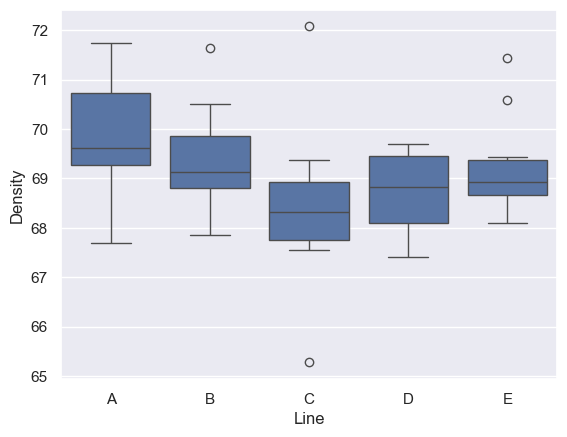

In [5]:
#箱ひげ図
sns.boxplot(x="Line",y="Density",data=data)

<Axes: xlabel='Line', ylabel='Density'>

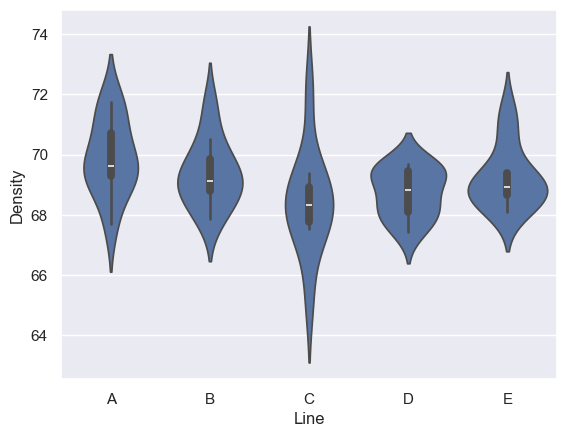

In [9]:
#バイオリンプロット
sns.violinplot(x="Line",y="Density",data=data)

In [16]:
#製造ラインごとの濃度の平均値
me_lineA=np.mean(data.query("Line=='A'")["Density"])
me_lineB=np.mean(data.query("Line=='B'")["Density"])
me_lineC=np.mean(data.query("Line=='C'")["Density"])
me_lineD=np.mean(data.query("Line=='D'")["Density"])
me_lineE=np.mean(data.query("Line=='E'")["Density"])
print("Line A:",me_lineA)
print("Line B:",me_lineB)
print("Line C:",me_lineC)
print("Line D:",me_lineD)
print("Line E:",me_lineE)

Line A: 69.9028591091939
Line B: 69.36865005840154
Line C: 68.42904350984494
Line D: 68.73809656689362
Line E: 69.23379915563066


In [24]:
#全データの濃度の平均値
mu_total=np.mean(data["Density"])
print("total:",mu_total)

total: 69.13448967999292


In [41]:
#効果の平方和を算出
#①各ラインの平均値が並んだリストを作成し、ndarrayに変換
mu_n_list=[me_lineA]*data.query("Line=='A'").shape[0]+\
[me_lineB]*data.query("Line=='A'").shape[0]+\
[me_lineC]*data.query("Line=='A'").shape[0]+\
[me_lineD]*data.query("Line=='A'").shape[0]+\
[me_lineE]*data.query("Line=='A'").shape[0]

mu_n=np.array(mu_n_list)

#②効果
effect=mu_n-mu_total

#③効果の平方和
squares_line=np.sum(effect**2)
print("効果の平方和：",squares_line)

効果の平方和： 13.098668335875512


In [31]:
#誤差の平方和を算出
#①誤差
resid=data["Density"]-mu_n

#②誤差の平方和
squares_resid=np.sum(resid**2)
print("誤差の平方和：",squares_resid)

誤差の平方和： 67.4069531127806


In [40]:
#効果の自由度
df_line=len(set(data["Line"]))-1
print("効果の自由度：",df_line)

#誤差の自由度
df_resid=len(data.query("Line=='A'"))-1+\
len(data.query("Line=='B'"))-1+\
len(data.query("Line=='C'"))-1+\
len(data.query("Line=='D'"))-1+\
len(data.query("Line=='E'"))-1
print("誤差の自由度：",df_resid)

効果の自由度： 4
誤差の自由度： 45


In [42]:
#効果の分散を算出
valiance_line=squares_line/df_line
print("効果の分散：",valiance_line)

#誤差の分散を算出
variance_resid=squares_resid/df_resid
print("誤差の分散：",variance_resid)

効果の分散： 3.274667083968878
誤差の分散： 1.4979322913951245


In [45]:
#F比を算出
f_ratio=valiance_line/variance_resid
print("F比：",f_ratio)

F比： 2.1861249021602718


In [47]:
#p値を算出
1-sp.stats.f.cdf(x=f_ratio,dfn=df_line,dfd=df_resid)

#p値が優位水準の0.05を下回らなかった

np.float64(0.08574964851206646)

In [48]:
#Statsmodelsの命令を使って一元分散分析を実行
anova_model=smf.ols("Density~Line",data=data).fit()
sm.stats.anova_lm(anova_model,typ=2)

,sum_sq,df,F,PR(>F)
Line,13.098668,4.0,2.186125,0.08575
Residual,67.406953,45.0,NaN,NaN


p値が0.05を上回ったため、帰無仮説を棄却することはできない。

よって、「各ラインの母集団の平均値のどの組み合わせにおいても有意差があるとは言い切れない」という結果となった。